# 02 · Connectome vs controls

Runs an experiment from a config and shows the tables and figures. Same thing as `scripts/run_experiment.py`, just interactive.

If the connectome data isn't downloaded yet it runs the offline synthetic demo instead (the summary says so at the top).

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)  # configs and data paths are relative to the repo root

from IPython.display import Markdown, display

from flyres import plotting
from flyres.config import load_config
from flyres.connectome import FILES, cache_stem
from flyres.experiment import run_experiment

have_real = Path(f"data/cache/{cache_stem(5)}.npz").exists() or all((Path("data/raw") / f).exists() for f in FILES.values())
CONFIG = "configs/small.yaml" if have_real else "configs/demo_synthetic.yaml"
cfg = load_config(CONFIG)
print("config:", CONFIG)

config: configs/small.yaml


In [2]:
result = run_experiment(cfg)  # a few minutes for small.yaml

subgraph: using cached grow_n3000_w5_9e557c8c
data: SPY 2003-09-26 to 2026-09-18 (5,781 rows)
running 25 reservoir jobs (5 wirings x 5 seeds)
  [1/25] connectome         seed 0: 3.7s
  [2/25] connectome         seed 1: 3.5s
  [3/25] connectome         seed 2: 3.5s
  [4/25] connectome         seed 3: 3.5s
  [5/25] connectome         seed 4: 3.5s
  [6/25] degree_preserving  seed 0: 4.7s
  [7/25] degree_preserving  seed 1: 4.7s
  [8/25] degree_preserving  seed 2: 4.8s
  [9/25] degree_preserving  seed 3: 4.7s
  [10/25] degree_preserving  seed 4: 4.7s
  [11/25] weight_shuffle     seed 0: 3.5s
  [12/25] weight_shuffle     seed 1: 3.5s
  [13/25] weight_shuffle     seed 2: 3.4s
  [14/25] weight_shuffle     seed 3: 3.5s
  [15/25] weight_shuffle     seed 4: 3.5s
  [16/25] sign_shuffle       seed 0: 3.4s
  [17/25] sign_shuffle       seed 1: 3.4s
  [18/25] sign_shuffle       seed 2: 3.5s
  [19/25] sign_shuffle       seed 3: 3.4s
  [20/25] sign_shuffle       seed 4: 3.8s
  [21/25] erdos_renyi      

In [3]:
display(Markdown(result.summary))

# flybrain-reservoir: small

Run 2026-09-21 07:13. Connectome: male CNS v1.0, >= 5 synapses per edge. Market data: yfinance.

- Reservoir: 3,000 neurons (grow), 100 input neurons, readout from 300 neurons + the raw inputs (relative penalty 0.001); spectral radius 0.9 (spectral), leak 1.0, weights log1p
- Wirings: connectome, degree_preserving, weight_shuffle, sign_shuffle, erdos_renyi. Seeds: 5. Horizon: 1 day(s). Costs: 1.0 bps per unit turnover. Positions: sign.

## SPY: out-of-sample, 2007-09-26 to 2026-09-18 (18.9 years)

Up days in the test period: 54.9% (an always-long model gets this hit rate).

| model | IC | hit rate | Sharpe (net) | Sharpe (gross) | ann. return | max drawdown | turnover |
|---|---|---|---|---|---|---|---|
| connectome | 0.015 ± 0.007 | 0.537 ± 0.004 | 0.51 ± 0.05 | 0.55 ± 0.05 | 0.100 ± 0.010 | -0.36 ± 0.05 | 0.32 ± 0.04 |
| degree_preserving | 0.016 ± 0.004 | 0.537 ± 0.003 | 0.54 ± 0.07 | 0.58 ± 0.06 | 0.106 ± 0.013 | -0.38 ± 0.05 | 0.35 ± 0.02 |
| weight_shuffle | 0.015 ± 0.005 | 0.534 ± 0.003 | 0.47 ± 0.08 | 0.52 ± 0.08 | 0.094 ± 0.016 | -0.38 ± 0.05 | 0.33 ± 0.04 |
| sign_shuffle | 0.011 ± 0.002 | 0.535 ± 0.002 | 0.47 ± 0.07 | 0.51 ± 0.07 | 0.093 ± 0.014 | -0.38 ± 0.03 | 0.33 ± 0.03 |
| erdos_renyi | 0.015 ± 0.003 | 0.534 ± 0.001 | 0.48 ± 0.05 | 0.53 ± 0.05 | 0.095 ± 0.010 | -0.34 ± 0.05 | 0.34 ± 0.01 |
| linear_features | -0.006 | 0.538 | 0.39 | 0.41 | 0.077 | -0.46 | 0.18 |
| ar | 0.004 | 0.542 | 0.62 | 0.65 | 0.123 | -0.34 | 0.20 |
| buy_hold | n/a | 0.551 | 0.62 | 0.62 | 0.123 | -0.55 | 0.00 |

### Connectome minus each alternative

Per-seed paired differences (t-test over seeds) and the Sharpe difference of the seed-averaged strategies (moving-block bootstrap, 95% CI).

| comparison | Δ IC | Δ hit rate | Δ Sharpe (net) | ensemble Δ Sharpe [95% CI] |
|---|---|---|---|---|
| connectome vs degree_preserving | -0.001 (p=0.70) | -0.001 (p=0.68) | -0.03 (p=0.52) | -0.02 [-0.20, +0.13] (p=0.76) |
| connectome vs weight_shuffle | +0.000 (p=0.88) | +0.002 (p=0.14) | +0.03 (p=0.43) | -0.02 [-0.14, +0.09] (p=0.69) |
| connectome vs sign_shuffle | +0.004 (p=0.17) | +0.002 (p=0.38) | +0.04 (p=0.36) | +0.07 [-0.12, +0.26] (p=0.49) |
| connectome vs erdos_renyi | +0.000 (p=0.98) | +0.003 (p=0.17) | +0.03 (p=0.53) | -0.02 [-0.18, +0.12] (p=0.81) |
| connectome vs linear_features | +0.021 | -0.001 | +0.12 | +0.17 [-0.08, +0.40] (p=0.15) |
| connectome vs ar | +0.011 | -0.005 | -0.11 | -0.07 [-0.39, +0.23] (p=0.65) |
| connectome vs buy_hold | n/a | -0.014 | -0.11 | -0.07 [-0.40, +0.27] (p=0.70) |

Rule of thumb: the standard error of an annualized Sharpe over 19 years is about 0.23, so differences much smaller than that are noise.

## Memory capacity (market-free benchmark)

Sum over delays 1..100 of R² for reconstructing past i.i.d. inputs.

| wiring | memory capacity | connectome minus this |
|---|---|---|
| connectome | 9.17 ± 0.12 | - |
| degree_preserving | 10.46 ± 0.30 | -1.28 (p=0.00) |
| weight_shuffle | 9.27 ± 0.23 | -0.09 (p=0.18) |
| sign_shuffle | 9.99 ± 1.68 | -0.82 (p=0.32) |
| erdos_renyi | 11.01 ± 0.49 | -1.84 (p=0.00) |

## Wiring structure (before rescaling)

| wiring | edges | reciprocity | largest SCC | raw gain |
|---|---|---|---|---|
| connectome | 200,172 | 0.360 | 0.99 | 251.71 |
| degree_preserving | 200,172 | 0.036 ± 0.000 | 0.99 ± 0.00 | 65.05 ± 2.96 |
| weight_shuffle | 200,172 | 0.360 | 0.99 | 222.97 ± 0.93 |
| sign_shuffle | 200,172 | 0.360 | 0.99 | 114.68 ± 29.42 |
| erdos_renyi | 200,172 | 0.022 ± 0.001 | 1.00 | 54.20 ± 1.85 |

## Reading this

- p-values come from paired tests over seeds (seed = input weights, readout neurons, control randomness). They capture seed-to-seed variation, not luck in the market history; the ensemble bootstrap covers that part.
- A model that learns nothing predicts the average (positive) return and turns into buy & hold, so compare Sharpe against buy & hold and hit rate against the up-day rate. IC is the cleanest skill measure.
- Several comparisons are run at once, so expect the odd p < 0.05 by chance.


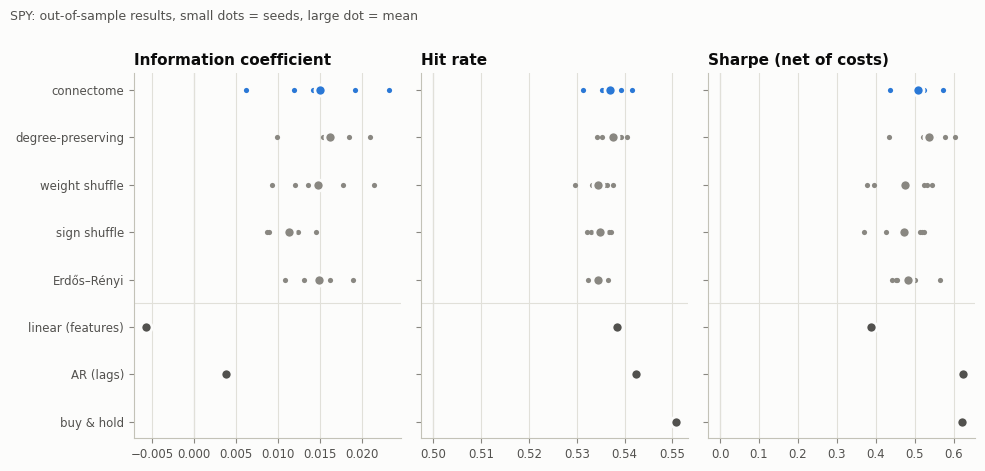

In [4]:
for ticker in result.ensemble_returns:
    plotting.plot_metric_strip(result.metrics, ticker)

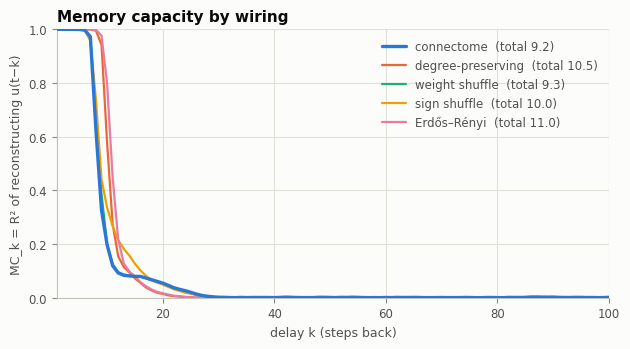

In [5]:
plotting.plot_memory_curves(result.memory);

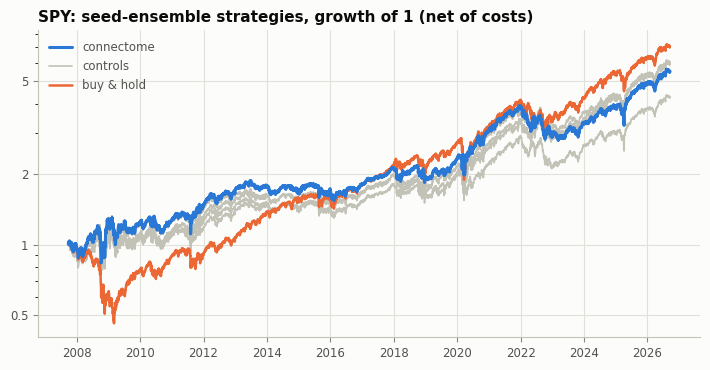

In [6]:
for ticker, ens in result.ensemble_returns.items():
    test = ens.dropna(how="all")
    plotting.plot_equity({c: test[c].to_numpy() for c in test.columns}, test.index,
                         title=f"{ticker}: seed-ensemble strategies, growth of 1 (net of costs)")

## What would count as evidence that the fly wiring is special

- The connectome beats **each** control with the same sign across seeds, not just on average.
- It survives multiple comparisons (five controls × several metrics is a lot of chances to get p < 0.05 by luck).
- The seed-ensemble bootstrap interval excludes zero.
- It shows up in memory capacity too, and at a second subgraph size (`--set subgraph.n_neurons=...`).

The most likely outcome on daily SPY is that nothing beats buy & hold or the linear baseline by a meaningful margin. That's fine: memory capacity is the cleaner test of whether biological wiring is special as a reservoir.